In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
df  = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

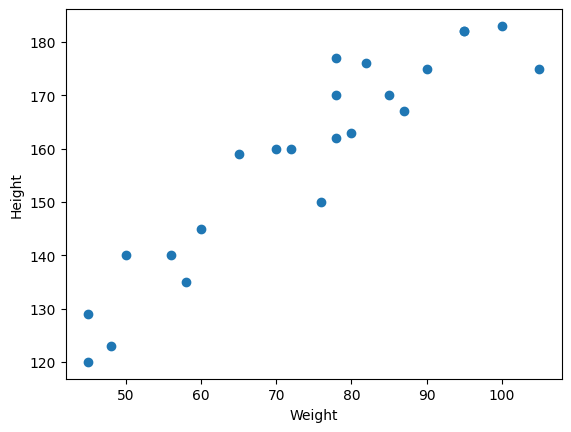

In [6]:
plt.scatter(df['Weight'],df['Height'] )
plt.xlabel("Weight")
plt.ylabel("Height")

### correlation

In [9]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


### seaborn for visualization

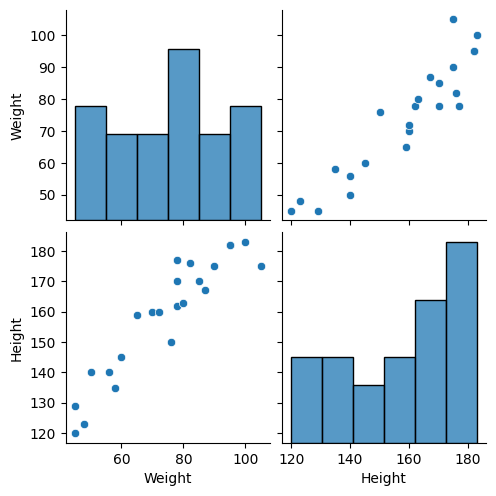

In [10]:
import seaborn as sns
sns.pairplot(df)

### separate Independent and dependent feature

In [13]:
X = df[["Weight"]] # independent feature should be dataframe or 2 dimenionalarray
y = df['Height'] ## this variable can be in series or 1 d array
np.array(X).shape

(23, 1)

### what if we take 1 d array as independent feature

In [14]:
X_series = df['Weight']
print(np.array(X_series).shape)
print(np.array(y).shape)

(23,)
(23,)


## Spliting training and testing data

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
X_train, X_test , y_train , y_test  = train_test_split(X , y , test_size= 0.25 , random_state= 42)

## Standardization

Standardization (often called Z-score normalization) is a fundamental data preprocessing step in machine learning. It involves rescaling the features (columns) of your dataset so that they look like a standard normal distribution.When you standardize data, you shift and scale the numbers so that the mean (average) becomes 0 and the standard deviation becomes 1.



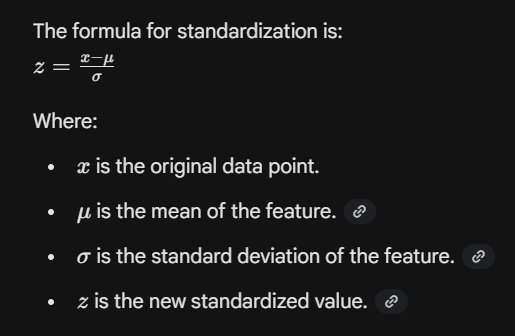


### Why is Standardization Important in Machine Learning?
In raw real-world data, features often have drastically different scales. For example, a dataset about houses might have "number of bedrooms" ranging from 1 to 5, and "price" ranging from $100,000 to $1,000,000. This massive difference in scale can completely confuse many machine learning models.

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [22]:
X_train = scaler.fit_transform(X_train)

In [23]:
X_test = scaler.transform(X_test)

In [24]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [ ]:
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

### Apply Simple Linear Regression 

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
regression = LinearRegression(n_jobs = -1)

### error comes when we dont use 2d array for the independent feature

In [53]:
regression.fit(y_train , X_series)

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.



### What does n_jobs mean?
The n_jobs parameter stands for "number of jobs." It controls how many concurrent processes or threads are used to run the algorithm in parallel.

n_jobs = 1 (Default): The algorithm runs on a single CPU core.

n_jobs = 2: The algorithm splits the work across two CPU cores.

n_jobs = -1: This is a special instruction that means "do not hold back; use 100% of the processors available on my machine."

### Why is it useful?
Using -1 allows the model to utilize parallel processing, which can significantly speed up the training time of your model.

In [28]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
print("coefficient or slope: ", regression.coef_)
print("Intercept: ", regression.intercept_)

coefficient or slope:  [17.2982057]
Intercept:  156.47058823529412


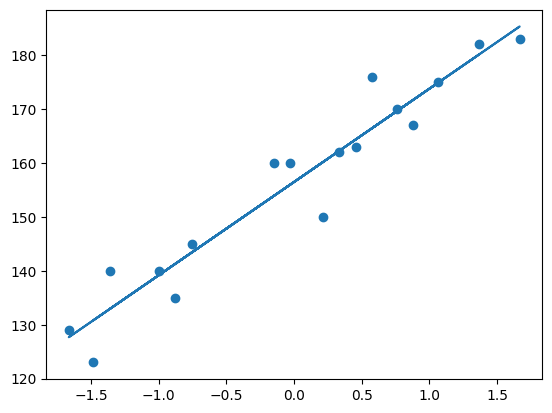

In [31]:
plt.scatter(X_train , y_train )
plt.plot(X_train , regression.predict(X_train))

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [35]:
y_pred = regression.predict(X_test)

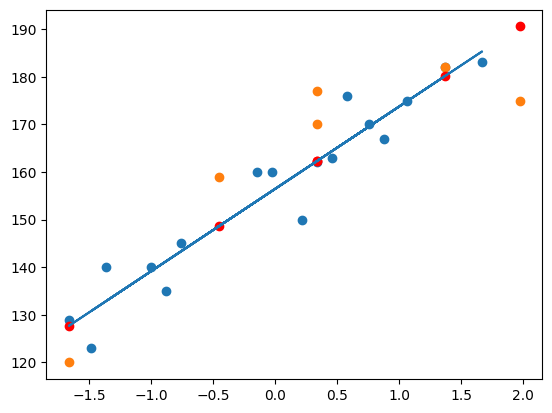

In [38]:
plt.scatter(X_train , y_train )
plt.plot(X_train , regression.predict(X_train))
plt.scatter(X_test , y_test)
plt.scatter(X_test , y_pred , color = 'red')

## Performance Metrics


In [39]:

from sklearn.metrics import mean_absolute_error,mean_squared_error

In [40]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [41]:
from sklearn.metrics import r2_score

In [42]:
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [43]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

## OLS Linear Regression


In [46]:
import statsmodels.api as sm

In [45]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 2.6 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.6 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.6 MB 2.5 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.6 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.6 MB 2.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.4 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.6 MB 2.4 MB/s eta 0:00:03
   --------------------- ------------------ 5.2/9.6 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 2.4 MB/s eta 0:00:02
   -----------------------

In [47]:
model=sm.OLS(y_train,X_train).fit()


In [48]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [49]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 10 Mar 2026   Prob (F-statistic):                       0.664
Time:                        11:33:03   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## Prediction For new data

#### without standardization

In [52]:
regression.predict([[72]])

array([1401.94139895])

#### with standardization

In [50]:
regression.predict(scaler.transform([[72]]))

c:\Users\skpri\anaconda3\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])